In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')
nhts_data = pd.read_csv("NHTS.csv")
nhts_data.head()
nhts_data.describe()
nhts_data['vehicle_type'].value_counts()
nhts_data.isnull().sum()


household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')
nhts_data = pd.read_csv("NHTS.csv")
nhts_data.head()
nhts_data.describe()
nhts_data['vehicle_type'].value_counts()
nhts_data.isnull().sum()


household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

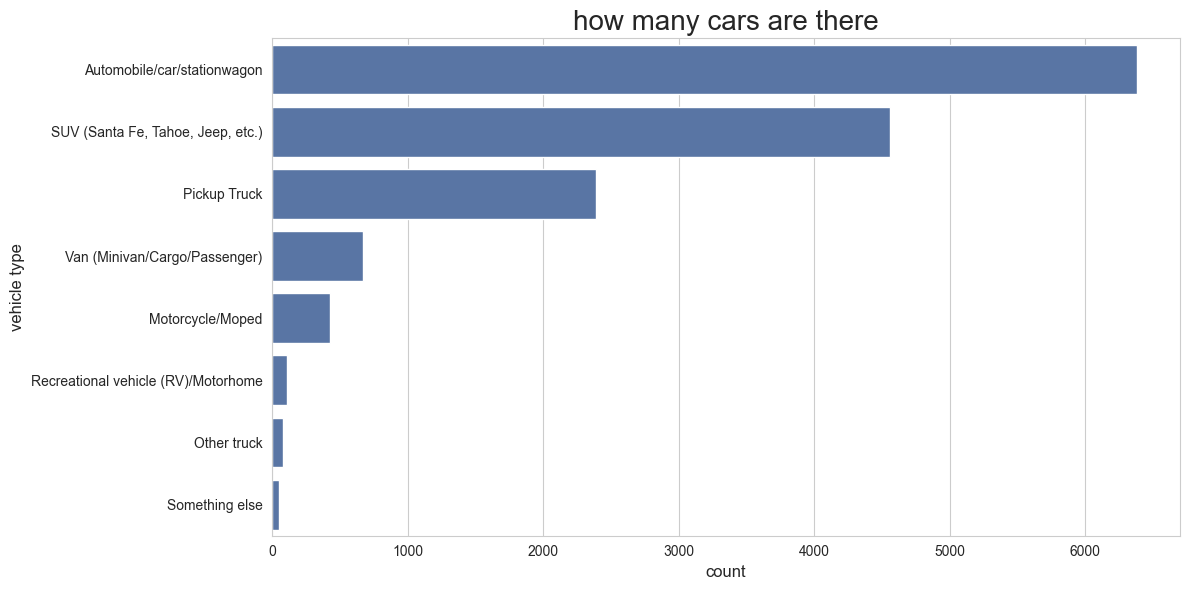

In [3]:
plt.figure(figsize = (12,6))
sns.countplot(data = nhts_data, y = 'vehicle_type', order = nhts_data['vehicle_type'].value_counts().index)
plt.xlabel('count', fontsize = 12)
plt.ylabel('vehicle type', fontsize = 12)
plt.title('how many cars are there', fontsize = 20)
plt.tight_layout()
plt.show()


<Figure size 2000x2000 with 0 Axes>

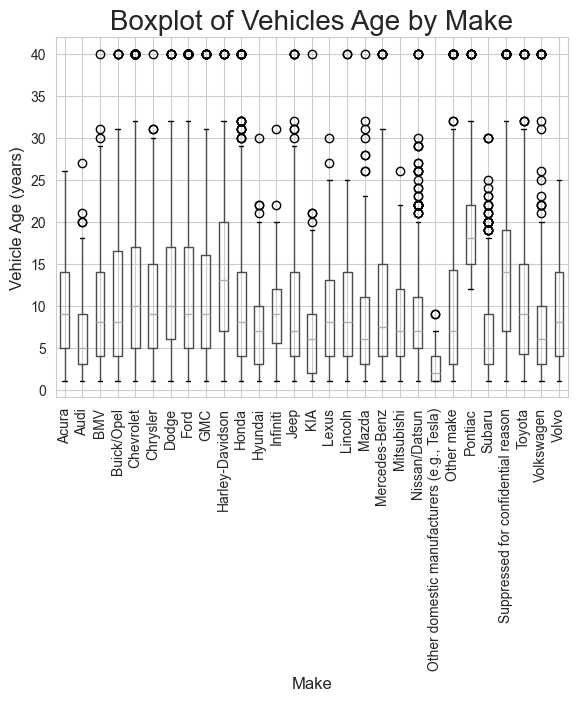

In [4]:
plt.figure(figsize = (20,20))
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make')
plt.xticks(rotation = 90)
plt.xlabel('Make', fontsize = 12)
plt.ylabel('Vehicle Age (years)', fontsize = 12)
plt.title('Boxplot of Vehicles Age by Make', fontsize = 20)
plt.suptitle('')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

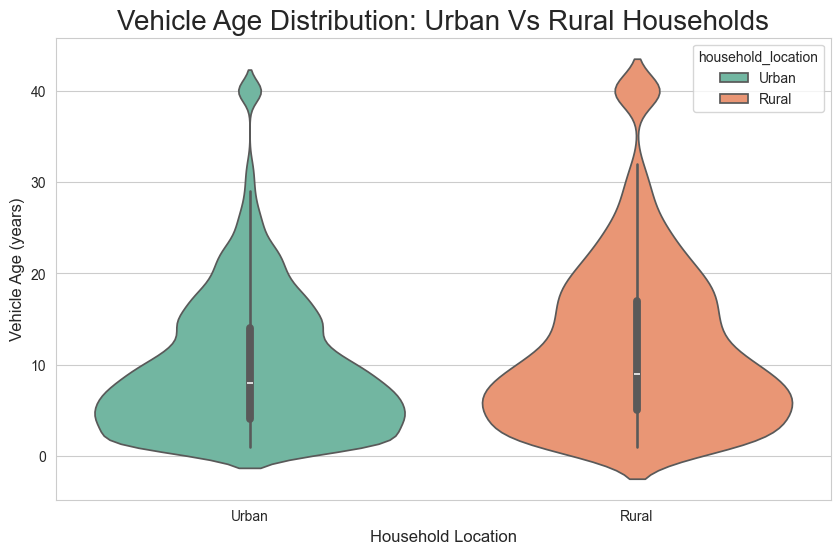

In [5]:
plt.figure(figsize = (10,6))
sns.violinplot(data = nhts_data, x = 'household_location', y = 'vehicle_age', hue = 'household_location', palette = 'Set2', legend = True)
plt.xlabel("Household Location", fontsize = 12)
plt.ylabel("Vehicle Age (years)", fontsize = 12)
plt.title("Vehicle Age Distribution: Urban Vs Rural Households", fontsize = 20)
plt.suptitle('')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

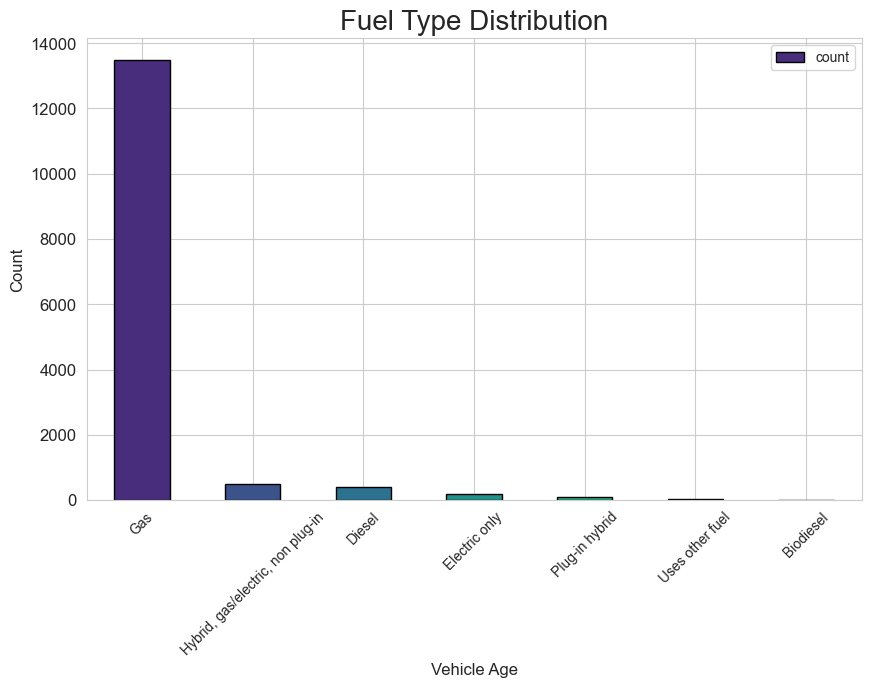

In [6]:
fuel_counts = nhts_data["fuel_type"].value_counts().dropna()
plt.figure(figsize = (10,6))
fuel_counts.plot(kind = 'bar', edgecolor = 'black', color = sns.color_palette('viridis', len(fuel_counts)))
plt.xlabel("Vehicle Age", fontsize = 12)
plt.ylabel("Count", fontsize = 12)
plt.xticks(rotation = 45, fontsize = 10)
plt.yticks(fontsize = 12)
plt.title("Fuel Type Distribution", fontsize = 20)
plt.legend()
plt.show


In [7]:
ngsim_data = pd.read_csv("NGSIM.csv")
ngsim_data
print("Columns in dataset:", ngsim_data.columns)
print("Dataset info:")
print(ngsim_data.info())
ngsim_data.describe()
print(ngsim_data['trajectory_number'].unique())
print(ngsim_data.groupby('trajectory_number').size())


Columns in dataset: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  8166 non-null   float64
 1   leader_position(m)    8166 non-null   float64
 2   follower_position(m)  8166 non-null   float64
 3   leader_speed(m/s)     8166 non-null   float64
 4   follower_speed(m/s)   8166 non-null   float64
 5   leader_acc(m/s^2)     8166 non-null   float64
 6   follower_acc(m/s^2)   8166 non-null   float64
 7   trajectory_number     8166 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 510.5 KB
None
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
trajectory_number
1     841
2     39

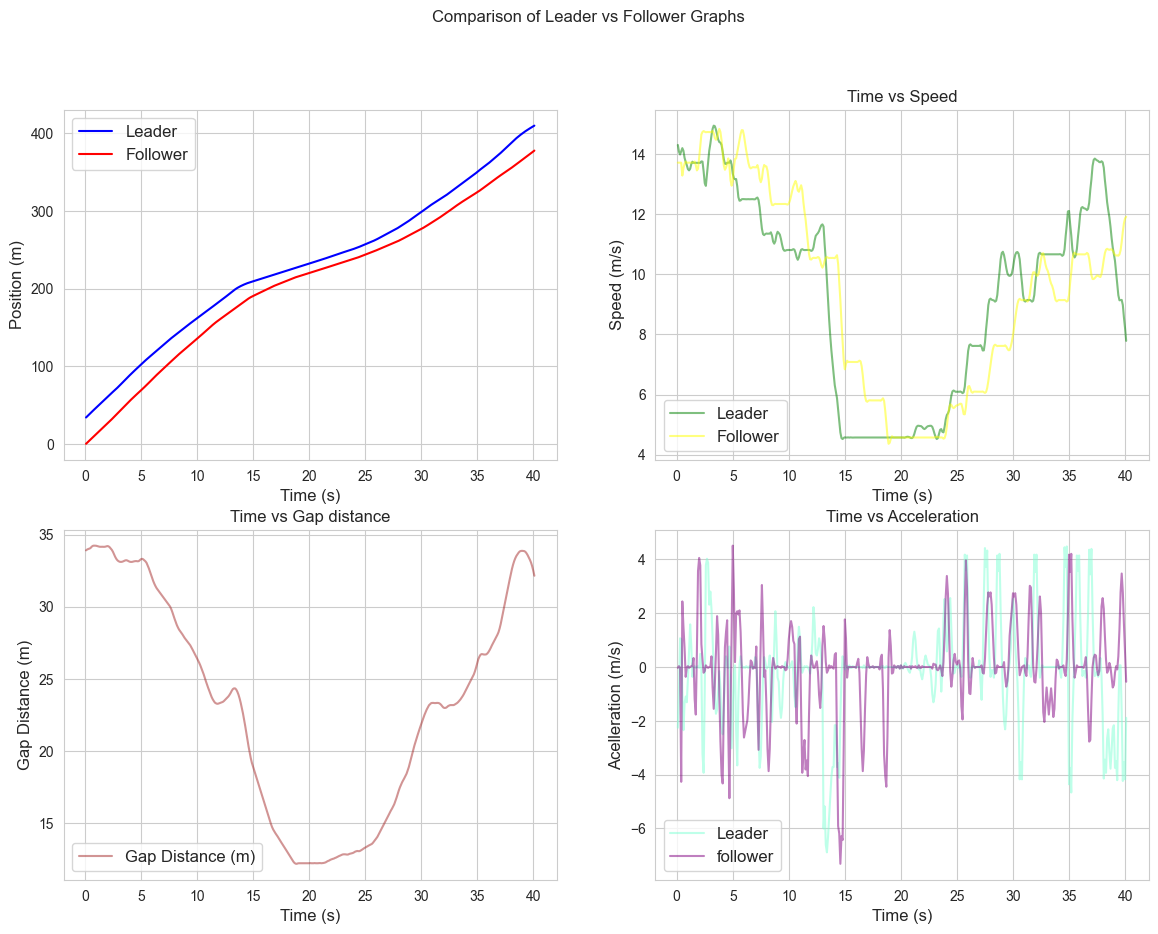

In [8]:
trajectory_number = 5
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(time, data_subset['leader_position(m)'].values, linewidth = 1.5, label = 'Leader', color = 'blue')
axes[0,0].plot(time, data_subset['follower_position(m)'].values, linewidth = 1.5, label = 'Follower', color = 'red')
axes[0,0].set_ylabel('Position (m)', fontsize = 12)
axes[0,0].set_xlabel('Time (s)', fontsize = 12)
axes[0,1].set_title('Time vs Position', fontsize = 12)
axes[0,0].legend(fontsize = 12)
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, linewidth = 1.5, label = 'Leader', color = 'green', alpha = 0.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, linewidth = 1.5, label = 'Follower', color = 'yellow', alpha = 0.5)
axes[0,1].set_ylabel('Speed (m/s)', fontsize = 12)
axes[0,1].set_xlabel('Time (s)', fontsize = 12)
axes[0,1].set_title('Time vs Speed', fontsize = 12)
axes[0,1].legend(fontsize = 12)
axes[1,1].plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth = 1.5, label = 'Leader', color = 'aquamarine', alpha = 0.5)
axes[1,1].plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth = 1.5, label = 'follower', color = 'purple', alpha = 0.5)
axes[1,1].set_ylabel('Acelleration (m/s)', fontsize = 12)
axes[1,1].set_xlabel('Time (s)', fontsize = 12)
axes[1,1].set_title('Time vs Acceleration', fontsize = 12)
axes[1,1].legend(fontsize = 12)
axes[1,0].plot(time, gap_distance, linewidth = 1.5, label = 'Gap Distance (m)', color = 'brown', alpha = 0.5)
axes[1,0].set_ylabel('Gap Distance (m)', fontsize = 12)
axes[1,0].set_xlabel('Time (s)', fontsize = 12)
axes[1,0].set_title('Time vs Gap distance', fontsize = 12)
axes[1,0].legend(fontsize = 12)
fig.suptitle('Comparison of Leader vs Follower Graphs')
plt.show()


In [9]:
ngsim = pd.read_csv('NGSIM.csv')
trajectorynumber = 5
datasubset = ngsim[ngsim['trajectory_number'] == trajectorynumber].reset_index(drop = True)
timedata = datasubset['Time'].values
leaderposition = datasubset['leader_position(m)'].values
leaderspeed = datasubset['leader_speed(m/s)'].values
dt = 0.1


In [18]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)
    return acceleration

In [19]:
ngsim = pd.read_csv('NGSIM.csv')
trajectorynumber = 2
datasubset = ngsim[ngsim['trajectory_number'] == trajectorynumber].reset_index(drop = True)
timedata = datasubset['Time'].values
leaderposition = datasubset['leader_position(m)'].values
leaderspeed = datasubset['leader_speed(m/s)'].values
dt = 0.1
v0 = 30
s0 = 2
T = 1.5
a_param = 1.0
b = 1.5
delta = 4
nsteps = len(timedata)
simposition = np.zeros(nsteps)
simspeed = np.zeros(nsteps)
simacc = np.zeros(nsteps)
simposition[0] = datasubset['follower_position(m)'].values[0]
simspeed[0] = datasubset['follower_speed(m/s)'].values[0]
for i in range(nsteps - 1):
    gap = max(leaderposition[i] - simposition[i], .1)
    delta_v = simspeed[i] - leaderspeed[i]
    simacc[i] = idm_acceleration(simspeed[i], gap, delta_v, v0, s0, T, a_param, b, delta)
    simspeed[i+1] = max(simspeed[i] + simacc[i] * dt,0)
    simposition[i+1] = simposition[i] + simspeed[i] * dt
print("Simulation complete!")

Simulation complete!


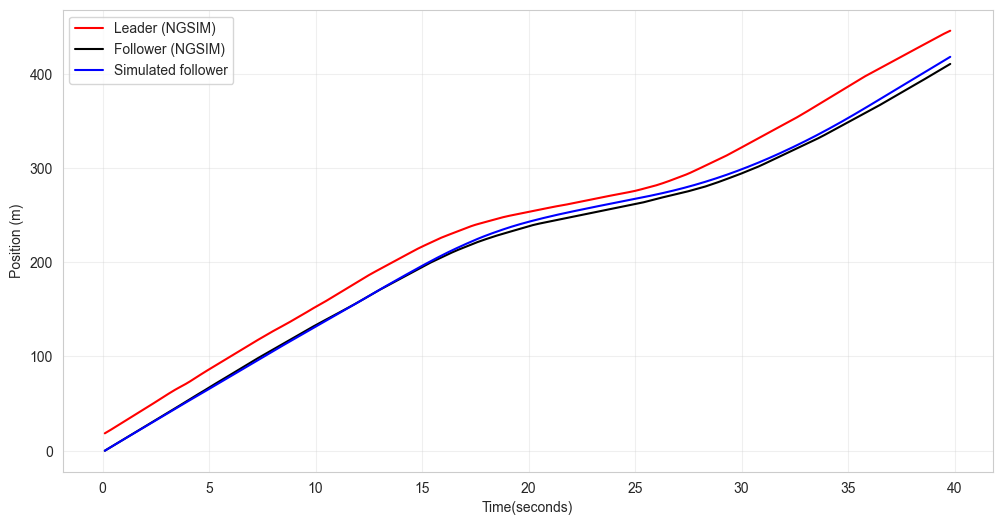

In [20]:
plt.figure(figsize = (12,6))
plt.plot(timedata, leaderposition, label = 'Leader (NGSIM)', color = 'red')
plt.plot(timedata, datasubset['follower_position(m)'].values, label = 'Follower (NGSIM)', color = 'black')
plt.plot(timedata, simposition, label = "Simulated follower", color = 'blue')
plt.xlabel('Time(seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = .3)
plt.show()
